In [1]:
import pandas as pd
from pandas import IndexSlice as idx
import numpy as np
import warnings
warnings.filterwarnings('ignore')
# pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
from matplotlib import rcParams
import math
import seaborn as sns
from scipy.stats import spearmanr
from typing import List, Optional
from collections import Counter
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# Data Preparation

In [2]:
# Obtain the daily frequency market data of all A-share stocks from 2010 to September 30, 2025
stock_daily = pd.read_parquet('data/China_A_Share_Market_Daily_Quotes.parquet')
stock_daily = stock_daily[['open','close','high','low','volume','is_st','is_special_st','trading_status']]

In [3]:
stock_daily

open     close      high       low      volume  \
trade_date code                                                            
2010-01-04 000001.SZ    6.6804    6.4598    6.6968    6.4516  24192276.0   
           000002.SZ    6.6164    6.4639    6.6286    6.4639  96983253.0   
           000004.SZ   10.0000   10.0000   10.0000   10.0000         NaN   
           000006.SZ    3.1429    3.0846    3.1484    3.0818   6299805.0   
           000007.SZ    4.7257    4.6190    4.7257    4.5990   2590179.0   
...                        ...       ...       ...       ...         ...   
2025-09-30 920978.BJ   40.3000   38.8000   41.1800   38.0000   6235146.0   
           920981.BJ   37.3600   37.0100   37.8800   36.8100   1091803.0   
           920982.BJ  285.0700  281.5900  286.7000  281.0000    537536.0   
           920985.BJ    9.3300    9.2400    9.4800    9.2300   2605370.0   
           920992.BJ   21.1500   21.0700   21.3200   21.0200    931100.0   

                     is_st is_special_st      trading_status  
trade_date code                                               
2010-01-04 000001.SZ     N             N      Normal Trading  
           000002.SZ     N             N      Normal Trading  
           000004.SZ     N             Y  Trading Suspension  
           000006.SZ     N             N      Normal Trading  
           000007.SZ     Y             N      Normal Trading  
...                    ...           ...                 ...  
2025-09-30 920978.BJ     N             N      Normal Trading  
           920981.BJ     N             N      Normal Trading  
           920982.BJ     N             N      Normal Trading  
           920985.BJ     N             N      Normal Trading  
           920992.BJ     N             N      Normal Trading  

[12793734 rows x 8 columns]

In [4]:
# Take a look at the column "traidng_status", and you can see that it contains multiple transaction statuses
Counter(stock_daily['trading_status'])

Counter({'Normal Trading': 12411048,
         'Trading Suspension': 329866,
         'Resumed Trading': 29395,
         'One-Day Trading Halt': 19102,
         'Intraday Trading Pause': 2257,
         'One-Hour Trading Halt': 1940,
         'Half-Day Trading Halt': 126})

In [5]:
# To facilitate the subsequent screening of the stock pool, we simply divide it into two categories: normal trading and suspended trading

# Define replacement rules
REPLACEMENT_RULES = {
    'Normal Trading': 'Normal Trading',  
    'Trading Suspension': 'Halted',
    'Resumed Trading': 'Normal Trading', 
    'One-Day Trading Halt': 'Halted',
    'Intraday Trading Pause': 'Halted',
    'One-Hour Trading Halt': 'Halted',
    'Half-Day Trading Halt': 'Halted'
}

stock_daily['trading_status'] = stock_daily['trading_status'].map(REPLACEMENT_RULES)

In [6]:
Counter(stock_daily['trading_status'])

Counter({'Normal Trading': 12440443, 'Halted': 353291})

In [7]:
# Merge the columns is_st and is_special_st of the data directly into one column
stock_daily['is_st'] = np.where(
    (stock_daily['is_st'] == 'Y') | (stock_daily['is_special_st'] == 'Y'), 
    'Y', 
    'N'
)
stock_daily.drop('is_special_st', axis=1, inplace=True)

In [8]:
stock_daily

open     close      high       low      volume  \
trade_date code                                                            
2010-01-04 000001.SZ    6.6804    6.4598    6.6968    6.4516  24192276.0   
           000002.SZ    6.6164    6.4639    6.6286    6.4639  96983253.0   
           000004.SZ   10.0000   10.0000   10.0000   10.0000         NaN   
           000006.SZ    3.1429    3.0846    3.1484    3.0818   6299805.0   
           000007.SZ    4.7257    4.6190    4.7257    4.5990   2590179.0   
...                        ...       ...       ...       ...         ...   
2025-09-30 920978.BJ   40.3000   38.8000   41.1800   38.0000   6235146.0   
           920981.BJ   37.3600   37.0100   37.8800   36.8100   1091803.0   
           920982.BJ  285.0700  281.5900  286.7000  281.0000    537536.0   
           920985.BJ    9.3300    9.2400    9.4800    9.2300   2605370.0   
           920992.BJ   21.1500   21.0700   21.3200   21.0200    931100.0   

                     is_st  trading_status  
trade_date code                             
2010-01-04 000001.SZ     N  Normal Trading  
           000002.SZ     N  Normal Trading  
           000004.SZ     Y          Halted  
           000006.SZ     N  Normal Trading  
           000007.SZ     Y  Normal Trading  
...                    ...             ...  
2025-09-30 920978.BJ     N  Normal Trading  
           920981.BJ     N  Normal Trading  
           920982.BJ     N  Normal Trading  
           920985.BJ     N  Normal Trading  
           920992.BJ     N  Normal Trading  

[12793734 rows x 7 columns]

In [9]:
def identify_recently_removed_st(stock_daily, window_trading_days=63):
    """
    Identify stocks that have been delisted from ST within N trading days

    Parameter
    stock_daily: DataFrame with (trade_date, code) index, with is_st column required
    window_trading_days: Observation window days (default 63≈3 months)

    Return
    Series: Indicates whether it is within the cap removal window period (bool type)
    The index is consistent with the input data
    """
    # 1. Make sure the data is sorted by time
    df_sorted = stock_daily.sort_index(level=['trade_date', 'code'])
    
    # 2. Detect the changes in ST status
    st_changes = df_sorted.groupby('code')['is_st'].transform(
        lambda x: x.ne(x.shift()) & (x.shift().notna()) & (x == 'N')
    )
    
    # 3. Mark the date of cap removal
    st_removal_date = pd.Series(index=df_sorted.index, dtype='datetime64[ns]')
    st_removal_date.loc[st_changes] = df_sorted.index.get_level_values('trade_date')[st_changes]
    
    # 4. The forward filling cap removal date
    st_removal_date = st_removal_date.groupby('code').ffill()
    
    # 5. Calculate the number of trading days after delisting
    trading_day_counts = df_sorted.groupby(['code', st_removal_date]).cumcount()
    
    # 6. Generate the final tag column
    is_recently_removed = (
        (trading_day_counts <= window_trading_days) & 
        st_removal_date.notna()
    )
    
    return is_recently_removed

In [10]:
def identify_excessive_halt_stocks(stock_daily, window_days=20, max_halt_days=5):
    """
    Identify stocks that have been suspended for more than M days in the past N trading days

    Parameter
    stock_daily: A DataFrame containing (trade_date, code) index
    The trading_status column (including the 'suspended' status) must be included.
    window_days: Backtracking window days (default 20 trading days)
    max_halt_days: Maximum allowable suspension days (default 5 days)

    Return
    Series: Boolean value, True indicates that the number of days of suspension has exceeded the threshold
    The index is consistent with the input data
    """
    # Make sure the data is sorted by time
    df_sorted = stock_daily.sort_index(level=['trade_date', 'code'])
    
    # Calculate the number of trading suspension days in the past window_days
    halt_counts = df_sorted.groupby('code')['trading_status'].transform(
        lambda x: x.eq('Halted').rolling(window_days, min_periods=1).sum()
    )
    
    # Generate the final identifier
    is_excessive_halt = (halt_counts > max_halt_days)
    
    return is_excessive_halt

In [11]:
# For convenience, we also need to calculate the two indicators separately

# Stocks marked as ST delisted within three months (regarded as 63 trading days)
stock_daily['is_recently_removed_st'] = identify_recently_removed_st(stock_daily)
# Identify stocks that have been suspended for more than 5 days in the past 20 trading days
stock_daily['is_excessive_halt'] = identify_excessive_halt_stocks(stock_daily)

In [12]:
# Obtain the listing dates of all A-share stocks
A_Shares_Listing_Date = pd.read_excel('data/A-Shares_Listing_Date.xlsx')
A_Shares_Listing_Date

,code,symbol,ipo_date
0,000001.SZ,平安银行,1991-04-03
1,000002.SZ,万 科A,1991-01-29
2,000004.SZ,*ST国华,1990-12-01
3,000006.SZ,深振业A,1992-04-27
4,000007.SZ,全新好,1992-04-13
...,...,...,...
5432,920978.BJ,开特股份,2023-09-28
5433,920981.BJ,晶赛科技,2021-11-15
5434,920982.BJ,锦波生物,2023-07-20
5435,920985.BJ,海泰新能,2022-08-08


In [13]:
# Calculate another column of indicators to identify all the stocks that have been listed on the market for more than six months (180 days) on that day
def identify_mature_stocks(stock_daily, listing_date_df, min_listing_days=180):
    """
    Directly determine whether a stock has been listed for the specified number of days (default: 180 days ≈6 months)

    Parameter
    stock_daily: A DataFrame with a double-layer index (trade_date, code)
    listing_date_df: The listing date data containing code and ipo_date
    min_listing_days: Minimum time to market requirement (default 180 days)

    Return
    Series: Boolean value, True indicates that the required number of days on the market has been met
    The index is consistent with stock_daily
    """
    # 1. Reset index processing
    temp_df = stock_daily.reset_index()
    temp_df['trade_date'] = pd.to_datetime(temp_df['trade_date'])
    listing_date_df['ipo_date'] = pd.to_datetime(listing_date_df['ipo_date'])
    
    # 2. Merger listing date
    merged = temp_df.merge(
        listing_date_df[['code', 'ipo_date']],
        on='code',
        how='left'
    )
    
    # 3. Calculate the number of days on the market and make a direct judgment
    listing_age_days = (merged['trade_date'] - merged['ipo_date']).dt.days
    is_mature = listing_age_days >= min_listing_days
    
    # 4. Restore the original index
    is_mature.index = stock_daily.index
    
    return is_mature

is_mature_stock = identify_mature_stocks(stock_daily, A_Shares_Listing_Date, min_listing_days=180)

stock_daily['is_listing_mature'] = is_mature_stock

In [14]:
# Remove all stocks that are suspended from trading every day
stock_daily = stock_daily.loc[stock_daily['trading_status']=='Normal Trading']

In [15]:
stock_daily

open     close      high       low      volume  \
trade_date code                                                            
2010-01-04 000001.SZ    6.6804    6.4598    6.6968    6.4516  24192276.0   
           000002.SZ    6.6164    6.4639    6.6286    6.4639  96983253.0   
           000006.SZ    3.1429    3.0846    3.1484    3.0818   6299805.0   
           000007.SZ    4.7257    4.6190    4.7257    4.5990   2590179.0   
           000009.SZ    4.7236    4.6548    4.7364    4.6377  17362671.0   
...                        ...       ...       ...       ...         ...   
2025-09-30 920978.BJ   40.3000   38.8000   41.1800   38.0000   6235146.0   
           920981.BJ   37.3600   37.0100   37.8800   36.8100   1091803.0   
           920982.BJ  285.0700  281.5900  286.7000  281.0000    537536.0   
           920985.BJ    9.3300    9.2400    9.4800    9.2300   2605370.0   
           920992.BJ   21.1500   21.0700   21.3200   21.0200    931100.0   

                     is_st  trading_status  is_recently_removed_st  \
trade_date code                                                      
2010-01-04 000001.SZ     N  Normal Trading                   False   
           000002.SZ     N  Normal Trading                   False   
           000006.SZ     N  Normal Trading                   False   
           000007.SZ     Y  Normal Trading                   False   
           000009.SZ     N  Normal Trading                   False   
...                    ...             ...                     ...   
2025-09-30 920978.BJ     N  Normal Trading                   False   
           920981.BJ     N  Normal Trading                   False   
           920982.BJ     N  Normal Trading                   False   
           920985.BJ     N  Normal Trading                   False   
           920992.BJ     N  Normal Trading                   False   

                      is_excessive_halt  is_listing_mature  
trade_date code                                             
2010-01-04 000001.SZ              False               True  
           000002.SZ              False               True  
           000006.SZ              False               True  
           000007.SZ              False               True  
           000009.SZ              False               True  
...                                 ...                ...  
2025-09-30 920978.BJ              False               True  
           920981.BJ              False               True  
           920982.BJ              False               True  
           920985.BJ              False               True  
           920992.BJ              False               True  

[12440443 rows x 10 columns]

In [16]:
# Import the daily frequency market data of CITIC's first-level industries
csi_daily = pd.read_parquet('data/CITIC_Securities_Primary_Industry_Index_Daily_Quotes.parquet')
csi_daily

open     high      low    close  price_change  \
trade_date code                                                         
2010-01-04 CI005001  2518.75  2547.29  2463.78  2489.62        -16.21   
           CI005002  3379.80  3394.55  3314.77  3323.37        -35.14   
           CI005003  5629.37  5678.40  5550.17  5588.83        -14.78   
           CI005004  2112.26  2129.36  2079.49  2091.66         -9.60   
           CI005005  2478.97  2497.35  2438.47  2449.56        -18.40   
...                      ...      ...      ...      ...           ...   
2025-09-30 CI005026  9296.38  9425.22  9028.51  9077.82       -188.86   
           CI005027  7876.27  7958.50  7875.25  7909.93         96.88   
           CI005028  3602.47  3611.24  3579.72  3590.22          6.62   
           CI005029  3254.02  3263.60  3224.22  3240.95         22.23   
           CI005030   965.23   967.65   956.45   958.17         -9.25   

                     pct_change     volume     turnover  turnover_rate  
trade_date code                                                         
2010-01-04 CI005001       -0.65   44067.46    553515.46           0.51  
           CI005002       -1.05   22998.16    514704.99           1.16  
           CI005003       -0.26   52158.09    990488.29           1.58  
           CI005004       -0.46   60925.67    575830.69           0.95  
           CI005005       -0.75   51282.91    469107.37           0.82  
...                         ...        ...          ...            ...  
2025-09-30 CI005026       -2.04  302300.66  11617207.90           1.70  
           CI005027        1.24  701403.69  18551860.79           3.38  
           CI005028        0.18  501698.10   5833754.06           3.13  
           CI005029        0.69   47047.85    370596.33           2.32  
           CI005030       -0.96   21720.98    230132.90           1.75  

[112371 rows x 9 columns]

In [17]:
# Import the daily frequency constituent stock data of CITIC's first-level industries
csi_constituents_daily = pd.read_parquet('data/CITIC_Securities_Primary_Industry_Index_Daily_Constituents.parquet')
csi_constituents_daily

constituents
trade_date code                                                       
2010-01-04 CI005001  [000059.SZ, 000096.SZ, 000406.SZ, 000554.SZ, 0...
           CI005002  [000159.SZ, 000552.SZ, 000571.SZ, 000723.SZ, 0...
           CI005003  [000060.SZ, 000426.SZ, 000612.SZ, 000630.SZ, 0...
           CI005004  [000027.SZ, 000037.SZ, 000531.SZ, 000539.SZ, 0...
           CI005005  [000515.SZ, 000569.SZ, 000629.SZ, 000655.SZ, 0...
...                                                                ...
2025-09-30 CI005026  [000032.SZ, 000034.SZ, 000063.SZ, 000070.SZ, 0...
           CI005027  [000004.SZ, 000034.SZ, 000066.SZ, 000158.SZ, 0...
           CI005028  [000156.SZ, 000606.SZ, 000607.SZ, 000665.SZ, 0...
           CI005029  [000009.SZ, 000025.SZ, 000158.SZ, 000526.SZ, 0...
           CI005030  [000567.SZ, 002316.SZ, 002423.SZ, 300773.SZ, 6...

[112371 rows x 1 columns]

In [18]:
# Considering that the CI005030 index only began to have data from the end of 2019, it is directly excluded
csi_daily = csi_daily.drop(
    csi_daily.loc[idx[:, 'CI005030'], :].index
)
csi_constituents_daily = csi_constituents_daily.drop(
    csi_constituents_daily.loc[idx[:, 'CI005030'], :].index
)

In [19]:
# Add a list for stocks to indicate the industry they belong to on that day
def add_sector(stock_daily, csi_constituents_daily):
    """Add belonging sector column to stock_daily"""
    # Explode constituents list
    sector_mapping = (
        csi_constituents_daily.explode('constituents')
        .reset_index()
        .rename(columns={
            'constituents': 'stock_code',
            'code': 'belonging_industry'
        })
    )
    
    # Merge and clean up
    result = (
        stock_daily.reset_index()
        .merge(
            sector_mapping[['trade_date', 'stock_code', 'belonging_industry']],
            left_on=['trade_date', 'code'],
            right_on=['trade_date', 'stock_code'],
            how='left'
        )
        .drop('stock_code', axis=1)
        .set_index(['trade_date', 'code'])
    )
    
    return result


stock_daily = add_sector(stock_daily, csi_constituents_daily)
# Remove stocks that do not belong to any industry
stock_daily.dropna(inplace=True)

In [20]:
stock_daily

open     close      high       low      volume  \
trade_date code                                                            
2010-01-04 000001.SZ    6.6804    6.4598    6.6968    6.4516  24192276.0   
           000002.SZ    6.6164    6.4639    6.6286    6.4639  96983253.0   
           000006.SZ    3.1429    3.0846    3.1484    3.0818   6299805.0   
           000007.SZ    4.7257    4.6190    4.7257    4.5990   2590179.0   
           000009.SZ    4.7236    4.6548    4.7364    4.6377  17362671.0   
...                        ...       ...       ...       ...         ...   
2025-09-30 688798.SH   90.5000   92.4300   93.3300   90.2000   5246872.0   
           688799.SH   56.6800   57.1800   57.5700   55.6800   2058297.0   
           688800.SH   75.3000   75.1200   77.4500   74.1800   7683859.0   
           688819.SH   32.3700   32.7000   32.9900   32.2000   8071434.0   
           688981.SH  138.5000  140.1300  142.0000  136.6000  98622900.0   

                     is_st  trading_status  is_recently_removed_st  \
trade_date code                                                      
2010-01-04 000001.SZ     N  Normal Trading                   False   
           000002.SZ     N  Normal Trading                   False   
           000006.SZ     N  Normal Trading                   False   
           000007.SZ     Y  Normal Trading                   False   
           000009.SZ     N  Normal Trading                   False   
...                    ...             ...                     ...   
2025-09-30 688798.SH     N  Normal Trading                   False   
           688799.SH     N  Normal Trading                   False   
           688800.SH     N  Normal Trading                   False   
           688819.SH     N  Normal Trading                   False   
           688981.SH     N  Normal Trading                   False   

                      is_excessive_halt  is_listing_mature belonging_industry  
trade_date code                                                                
2010-01-04 000001.SZ              False               True           CI005021  
           000002.SZ              False               True           CI005023  
           000006.SZ              False               True           CI005023  
           000007.SZ              False               True           CI005015  
           000009.SZ              False               True           CI005023  
...                                 ...                ...                ...  
2025-09-30 688798.SH              False               True           CI005025  
           688799.SH              False               True           CI005018  
           688800.SH              False               True           CI005025  
           688819.SH              False               True           CI005011  
           688981.SH              False               True           CI005025  

[11185287 rows x 11 columns]

In [21]:
price_panel = stock_daily.pivot_table(index='trade_date', columns='code', values='close')
price_panel

code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,688786.SH,688787.SH,688788.SH,688789.SH,688793.SH,688798.SH,688799.SH,688800.SH,688819.SH,688981.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.4598,6.4639,NaN,3.0846,4.6190,NaN,4.6548,2.9527,7.6843,5.5645,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,6.3481,6.3176,NaN,2.9958,4.7923,NaN,4.5346,2.9002,7.4459,5.4699,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,6.2391,6.3176,NaN,3.0042,4.7923,NaN,4.5303,2.9302,7.4676,5.6391,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,6.1710,6.2688,NaN,2.9792,4.6524,NaN,4.6162,2.8152,7.2943,5.3409,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,6.1573,6.3115,NaN,3.0513,4.6857,NaN,4.8395,2.8652,7.3665,5.2836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-24,11.4600,6.8400,10.65,9.2700,6.9700,2.85,11.3200,4.3700,9.1400,4.7100,...,28.38,122.22,55.95,82.80,29.99,90.87,57.85,80.43,31.43,134.98
2025-09-25,11.4000,6.8000,10.48,9.2800,6.9100,2.82,12.0800,4.2800,9.0600,4.6900,...,27.70,126.68,54.85,83.68,29.87,91.78,56.60,81.03,31.30,134.11
2025-09-26,11.4000,6.8000,10.48,9.5100,6.9400,2.90,11.6900,4.2200,9.1000,4.6600,...,27.18,118.91,52.92,83.25,29.66,89.75,56.66,75.00,31.50,132.27


In [22]:
class MonthlyFactorAnalyzer:
    """
    Monthly Factor Analysis Framework (Side-by-side Charts Version)
    """
    
    def __init__(self, factor_panel, price_panel, factor_name="factor"):
        """
        Initialize analyzer
        
        Parameters:
            factor_panel: Factor panel data (date×stock)
            price_panel: Price panel data (date×stock)  
            factor_name: Factor name for chart titles
        """
        self.factor_panel = factor_panel
        self.price_panel = price_panel
        self.factor_name = factor_name
        self.monthly_data = None
        
    def prepare_monthly_data(self):
        """Prepare monthly frequency data"""
        # Convert to long format
        factor_long = self.factor_panel.stack().reset_index()
        factor_long.columns = ['trade_date', 'code', 'factor_value']
        
        price_long = self.price_panel.stack().reset_index()  
        price_long.columns = ['trade_date', 'code', 'price']
        
        # Merge data
        merged_data = factor_long.merge(price_long, on=['trade_date', 'code'])
        merged_data['trade_date'] = pd.to_datetime(merged_data['trade_date'])
        
        # Extract month-end data points
        merged_data['year_month'] = merged_data['trade_date'].dt.to_period('M')
        monthly_last = merged_data.sort_values('trade_date').groupby(['code', 'year_month']).last().reset_index()
        
        # Calculate future 1-month returns
        monthly_last = monthly_last.sort_values(['code', 'trade_date'])
        monthly_last['future_return_1m'] = monthly_last.groupby('code')['price'].transform(
            lambda x: x.shift(-1) / x - 1
        )
        
        self.monthly_data = monthly_last.dropna(subset=['factor_value', 'future_return_1m'])
        return self.monthly_data
    
    def calculate_rank_ic(self):
        """Calculate monthly Rank IC series"""
        if self.monthly_data is None:
            self.prepare_monthly_data()
            
        ic_results = []
        
        for month, month_data in self.monthly_data.groupby('year_month'):
            valid_data = month_data[['factor_value', 'future_return_1m']].dropna()
            
            if len(valid_data) > 30:  # Minimum stock count requirement
                # Calculate Spearman rank correlation
                ic_value = valid_data[['factor_value', 'future_return_1m']].corr(method='spearman').iloc[0, 1]
                
                if not pd.isna(ic_value):
                    ic_results.append({
                        'date': month.start_time,
                        'IC': ic_value
                    })
        
        ic_series = pd.DataFrame(ic_results).set_index('date')['IC']
        return ic_series
    
    def calculate_group_excess_returns(self, groups=10):
        """Calculate grouped monthly excess returns (corrected grouping logic)"""
        if self.monthly_data is None:
            self.prepare_monthly_data()
            
        excess_results = []
        
        for month, month_data in self.monthly_data.groupby('year_month'):
            valid_data = month_data[['factor_value', 'future_return_1m']].dropna()
            
            if len(valid_data) > 100:  # Ensure sufficient stocks for grouping
                # Calculate market return (equal-weighted benchmark)
                market_return = valid_data['future_return_1m'].mean()
                
                # CORRECTED GROUPING: Ensure proper 1-10 grouping
                # Group 1 = lowest factor value, Group 10 = highest factor value
                valid_data['group'] = pd.qcut(
                    valid_data['factor_value'], 
                    q=groups, 
                    labels=False, 
                    duplicates='drop'
                )
                # FIX: Add 1 to get groups 1-10 (not 0-9)
                valid_data['group'] = valid_data['group'] + 1
                
                # Calculate excess returns over market
                group_excess = valid_data.groupby('group')['future_return_1m'].mean() - market_return
                
                for group_num, excess_ret in group_excess.items():
                    excess_results.append({
                        'date': month.start_time,
                        'group': group_num,
                        'excess_return': excess_ret
                    })
        
        return pd.DataFrame(excess_results)
    
    def plot_combined_charts(self, ic_series, excess_returns_df, figsize=(20, 8)):
        """Plot both charts side by side"""
        # Create figure with 2 subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=600)
        
        # ===== LEFT CHART: Rank IC Analysis =====
        # Plot monthly Rank IC bars
        bars = ax1.bar(ic_series.index, ic_series.values * 100, 
                      color='darkblue', alpha=0.7, width=20, label='Monthly RankIC')
        
        # Plot cumulative Rank IC line on secondary y-axis
        ax1_twin = ax1.twinx()
        cumulative_ic = ic_series.cumsum()
        line = ax1_twin.plot(cumulative_ic.index, cumulative_ic.values, 
                           color='red', linewidth=2, label='Cumulative RankIC')
        
        # Left chart properties
        ax1.set_xlabel('Date', fontsize=12)
        ax1.set_ylabel('Monthly RankIC (%)', color='blue', fontsize=12)
        ax1_twin.set_ylabel('Cumulative RankIC', color='red', fontsize=12)
        ax1.set_title(f'{self.factor_name} RankIC Analysis', fontsize=14, fontweight='bold')
        
        # Formatting for left chart
        ax1.yaxis.set_major_formatter(PercentFormatter(decimals=1))
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax1_twin.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        ax1.grid(True, alpha=0.3)
        ax1.xaxis.set_major_locator(mdates.YearLocator(1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # ===== RIGHT CHART: Group Excess Returns =====
        # Calculate average excess returns
        avg_excess = excess_returns_df.groupby('group')['excess_return'].mean() * 100
        avg_excess = avg_excess.sort_index()
        
        # Color-coding: Red for negative, blue for positive
        colors = ['red' if x < 0 else 'blue' for x in avg_excess.values]
        bars2 = ax2.bar(avg_excess.index, avg_excess.values, color=colors, alpha=0.7)
        
        # Right chart properties
        ax2.set_xlabel('Portfolio Group', fontsize=12)
        ax2.set_ylabel('Excess Return (%)', fontsize=12)
        ax2.set_title(f'{self.factor_name} Group Excess Returns', fontsize=14, fontweight='bold')
        ax2.set_xticks(range(1, 11))  # Force x-axis from 1 to 10
        
        # Value labels on bars
        for bar in bars2:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}%', ha='center', va='bottom' if height >= 0 else 'top',
                   fontsize=9)
        
        # Reference lines and grid for right chart
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax2.grid(True, alpha=0.3)
        
        # Adjust layout
        plt.tight_layout()
        return fig, (ax1, ax2)
    
    def analyze_factor(self, show_charts=True):
        """Complete factor analysis workflow"""
        print(f"Starting analysis for {self.factor_name} factor...")
        
        # Calculate Rank IC
        ic_series = self.calculate_rank_ic()
        print(f"RankIC analysis completed. Time range: {ic_series.index[0]} to {ic_series.index[-1]}")
        print(f"Total months analyzed: {len(ic_series)}")
        
        # Calculate excess returns
        excess_returns = self.calculate_group_excess_returns()
        print("Group excess returns analysis completed")
        
        # Verify grouping correctness
        group_range = excess_returns['group'].unique()
        print(f"Group range in results: {sorted(group_range)}")
        
        # Calculate key metrics
        mean_ic = ic_series.mean()
        ic_ir = ic_series.mean() / ic_series.std() * np.sqrt(12)
        hit_rate = (ic_series < 0).mean() if mean_ic < 0 else (ic_series > 0).mean()
        
        print(f"\n{self.factor_name} Factor Performance Summary:")
        print(f"Monthly RankIC Mean: {mean_ic:.4f}")
        print(f"Annualized ICIR: {ic_ir:.3f}")
        print(f"Hit Rate: {hit_rate:.2%}")
        
        # Display group excess returns summary
        group_summary = excess_returns.groupby('group')['excess_return'].mean() * 100
        print(f"\nGroup Excess Returns (%):")
        for group_num, ret in group_summary.items():
            print(f"Group {group_num}: {ret:.2f}%")
        
        # Generate combined charts
        if show_charts:
            fig, _ = self.plot_combined_charts(ic_series, excess_returns)
        else:
            # For backward compatibility, also generate individual charts
            fig1, _ = self.plot_rank_ic_chart(ic_series)
            fig2, _ = self.plot_group_excess_returns_chart(excess_returns)
            fig = (fig1, fig2)
        
        return {
            'ic_series': ic_series,
            'excess_returns': excess_returns,
            'metrics': {
                'mean_ic': mean_ic,
                'ic_ir': ic_ir,
                'hit_rate': hit_rate
            },
            'figure': fig
        }
    
    # Keep individual chart methods for backward compatibility
    def plot_rank_ic_chart(self, ic_series, figsize=(12, 6)):
        """Individual Rank IC chart (for backward compatibility)"""
        fig, ax1 = plt.subplots(figsize=figsize, dpi=600)
        
        bars = ax1.bar(ic_series.index, ic_series.values * 100, 
                      color='darkblue', alpha=0.7, width=20, label='Monthly RankIC')
        
        ax2 = ax1.twinx()
        cumulative_ic = ic_series.cumsum()
        line = ax2.plot(cumulative_ic.index, cumulative_ic.values, 
                       color='red', linewidth=2, label='Cumulative RankIC')
        
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Monthly RankIC (%)', color='blue')
        ax2.set_ylabel('Cumulative RankIC', color='red')
        ax1.set_title(f'{self.factor_name} RankIC Analysis', fontsize=14, fontweight='bold')
        
        ax1.yaxis.set_major_formatter(PercentFormatter(decimals=1))
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        ax1.grid(True, alpha=0.3)
        ax1.xaxis.set_major_locator(mdates.YearLocator(1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        plt.tight_layout()
        return fig, (ax1, ax2)
    
    def plot_group_excess_returns_chart(self, excess_returns_df, figsize=(10, 6)):
        """Individual excess returns chart (for backward compatibility)"""
        avg_excess = excess_returns_df.groupby('group')['excess_return'].mean() * 100
        avg_excess = avg_excess.sort_index()
        
        fig, ax = plt.subplots(figsize=figsize, dpi=600)
        
        colors = ['red' if x < 0 else 'blue' for x in avg_excess.values]
        bars = ax.bar(avg_excess.index, avg_excess.values, color=colors, alpha=0.7)
        
        ax.set_xlabel('Portfolio Group')
        ax.set_ylabel('Excess Return (%)')
        ax.set_title(f'{self.factor_name} Group Excess Returns', fontsize=14, fontweight='bold')
        ax.set_xticks(range(1, 11))
        
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}%', ha='center', va='bottom' if height >= 0 else 'top',
                   fontsize=9)
        
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig, ax

    def plot_long_short_performance(self, groups=10, figsize=(12, 6), save_path=None):

        if self.monthly_data is None:
            self.prepare_monthly_data()
        
        long_short_results = []
        
        for month, month_data in self.monthly_data.groupby('year_month'):
            valid_data = month_data[['factor_value', 'future_return_1m']].dropna()
            
            if len(valid_data) > 100:
                valid_data['group'] = pd.qcut(
                    valid_data['factor_value'], 
                    q=groups, 
                    labels=False, 
                    duplicates='drop'
                )
                valid_data['group'] = valid_data['group'] + 1
                
                group_returns = valid_data.groupby('group')['future_return_1m'].mean()
                
                if len(group_returns) >= groups:
                    long_return = group_returns[groups]
                    short_return = group_returns[1]
                    ls_return = long_return - short_return
                    
                    long_short_results.append({
                        'date': month.start_time,
                        'long': long_return,
                        'short': short_return,
                        'long_short': ls_return
                    })
        
        ls_df = pd.DataFrame(long_short_results).set_index('date')
        
        if len(ls_df) == 0:
            raise ValueError("No valid long-short return data calculated")
        
        # Calculate cumulative returns
        cum_long = (1 + ls_df['long']).cumprod()
        cum_short = (1 + ls_df['short']).cumprod()
        cum_ls = (1 + ls_df['long_short']).cumprod()
        
        # Create figure
        plt.close('all')
        fig, ax = plt.subplots(figsize=figsize, dpi=600)
        
        # Plot curves
        ax.plot(cum_long.index, cum_long, label=f'Long Portfolio (Group {groups})', 
                color='red', linewidth=2.5)
        ax.plot(cum_short.index, cum_short, label='Short Portfolio (Group 1)', 
                color='green', linewidth=2.5)
        ax.plot(cum_ls.index, cum_ls, label='Long-Short Portfolio', 
                color='blue', linewidth=3, linestyle='--')
        
        ax.set_ylabel('Cumulative Return', fontsize=12)

        y_max = max(cum_long.max(), cum_short.max(), cum_ls.max())

        y_min = 0  
        y_max_adjusted = max(10, y_max * 1.1)  
        

        y_interval = 2  
        y_ticks = list(range(0, int(y_max_adjusted) + y_interval, y_interval))

        ax.set_yticks(y_ticks)
        ax.set_ylim(y_min, y_max_adjusted)

        from matplotlib.ticker import FormatStrFormatter
        ax.yaxis.set_major_formatter(FormatStrFormatter('%d'))
    
        # Chart settings
        ax.set_title(f'{self.factor_name} Long-Short Performance', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date', fontsize=12)
        
        # Format axes
        ax.xaxis.set_major_locator(mdates.YearLocator(1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        
        # Grid and reference line
        ax.axhline(y=1, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
        ax.grid(True, alpha=0.3)
        
        # Legend
        ax.legend(loc='upper left', fontsize=10)
        
        # Statistics
        stats_text = f"""Performance Statistics (Annualized):
    Long Return: {ls_df['long'].mean() * 12:.1%}
    Short Return: {ls_df['short'].mean() * 12:.1%}
    Long-Short Return: {ls_df['long_short'].mean() * 12:.1%}
    Sharpe Ratio: {ls_df['long_short'].mean() / ls_df['long_short'].std() * np.sqrt(12):.2f}"""
        
        ax.text(0.02, 0.6, stats_text, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=300)

# Research stage

## Reversal characteristics in individual stock trends during the research stage: Taking lottery-type stocks as an example

Bali et al. (2011) studied the daily anomaly of maximum returns in the US stock market and found that the stocks with higher maximum single-day gains in the past month had the characteristics of high volatility and high skewness, close to lotteries, and there was a significant negative correlation between the maximum single-day increase and the expected returns of the stocks. Stocks that have experienced significant single-day gains in the past month are more likely to reverse in the future, fall rapidly and experience a "roller coaster" market. In practice, investors are willing to pay a higher price for lottery-type stocks in pursuit of extremely positive returns, which often leads to overvaluation of such stocks. As a result, they tend to have lower returns in the future and show a strong reversal effect in subsequent trends.

A large number of studies have shown that the A-share market also has the anomaly of maximum daily returns. For instance, we take the daily increase or decrease of an individual stock on the day with the largest increase or decrease over the past 20 days as the daily factor for the maximum return of the individual stock, represented as MAX20, where $Ret_{t}$is the increase or decrease of the individual stock on day t:

$$
MAX20 = MAX(Ret_{t},Ret_{t-1},Ret_{t-2},\cdots,Ret_{t-19})
$$

In [23]:
def calculate_max20_factor(stock_daily, window=20, min_periods=1):
    """
    Calculate the MAX20 factor: the maximum single-day return rate within the past N trading days

    Parameter
    stock_daily: A DataFrame containing the (trade_date, code) index, which must have a close column
    window: Review window period (default 20 days)
    min_periods: Minimum valid data points

    Return
    DataFrame: Time × MAX20 factor panel data of the stock. Early missing values are filled with NaN
    """
    df_sorted = stock_daily.sort_index(level=['trade_date', 'code']).copy()
    
    df_sorted['daily_return'] = df_sorted.groupby('code')['close'].pct_change()
    
    df_sorted['MAX20'] = df_sorted.groupby('code')['daily_return'].transform(
        lambda x: x.rolling(window, min_periods=min_periods).max()
    )

    df_reset = df_sorted.reset_index()
    max20_panel = df_reset.pivot_table(
        index='trade_date',
        columns='code', 
        values='MAX20'
    ).sort_index()
    
    return max20_panel

max20_factor = calculate_max20_factor(stock_daily)

In [24]:
max20_factor

code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,688786.SH,688787.SH,688788.SH,688789.SH,688793.SH,688798.SH,688799.SH,688800.SH,688819.SH,688981.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,-0.017292,-0.022633,NaN,-0.028788,0.037519,NaN,-0.025823,-0.017780,-0.031024,-0.017001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,-0.017170,0.000000,NaN,0.002804,0.037519,NaN,-0.000948,0.010344,0.002914,0.030933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,-0.010915,0.000000,NaN,0.002804,0.037519,NaN,0.018961,0.010344,0.002914,0.030933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,-0.002220,0.006812,NaN,0.024201,0.037519,NaN,0.048373,0.017761,0.009898,0.030933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-11,0.000000,0.006812,NaN,0.024201,0.037519,NaN,0.048373,0.017761,0.026471,0.030933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-24,0.012302,0.031019,0.050326,0.099644,0.016000,0.027397,0.100097,0.099323,0.021229,0.019108,...,0.061728,0.058271,0.051909,0.050561,0.019206,0.049113,0.096369,0.073137,0.073316,0.174466
2025-09-25,0.012302,0.031019,0.050326,0.099644,0.016000,0.027397,0.100097,0.099323,0.021229,0.019108,...,0.061728,0.058271,0.051909,0.050561,0.019206,0.049113,0.096369,0.066372,0.073316,0.174466
2025-09-26,0.012302,0.031019,0.050326,0.099644,0.016000,0.028369,0.100097,0.099323,0.021229,0.019108,...,0.061728,0.058271,0.051909,0.050561,0.019206,0.049113,0.096369,0.066372,0.073316,0.174466


In [25]:
def calculate_ret20_factor(stock_daily, window=20):
    """
    Calculate the Ret20 factor: the cumulative return rate over the past N trading days

    Parameter
    stock_daily: A DataFrame containing the (trade_date, code) index, which must have a close column
    window: Review window period (default 20 days)

    Return
    DataFrame: Time × stock's Ret20 factor panel data. Early missing values are filled with NaN
    """
    df_sorted = stock_daily.sort_index(level=['trade_date', 'code']).copy()
    
    df_sorted['Ret20'] = df_sorted.groupby('code')['close'].transform(
        lambda x: x.pct_change(periods=window)
    )

    df_reset = df_sorted.reset_index()
    ret20_panel = df_reset.pivot_table(
        index='trade_date',
        columns='code', 
        values='Ret20'
    ).sort_index()
    
    return ret20_panel

ret20_factor = calculate_ret20_factor(stock_daily)

In [26]:
ret20_factor

code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,688786.SH,688787.SH,688788.SH,688789.SH,688793.SH,688798.SH,688799.SH,688800.SH,688819.SH,688981.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2010-02-01,-0.104183,-0.112254,NaN,-0.075537,NaN,NaN,-0.035039,-0.005080,-0.113725,-0.100458,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-02,-0.082844,-0.104248,NaN,-0.058315,-0.002879,NaN,-0.026507,0.021550,-0.099894,-0.101154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-03,-0.013976,-0.087834,NaN,-0.044338,-0.038937,NaN,0.009492,NaN,-0.032875,-0.082371,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-04,-0.019867,-0.084625,NaN,-0.027927,-0.031989,NaN,0.090226,0.030749,-0.010899,-0.034358,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-05,-0.026538,-0.111115,NaN,-0.087274,-0.024375,NaN,-0.007997,0.056834,-0.072545,-0.051556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-24,-0.049751,0.014837,-0.056687,0.316761,-0.074369,-0.006969,0.200424,-0.076110,0.011062,-0.016701,...,0.045304,-0.150070,-0.179619,0.107989,-0.117162,-0.049278,0.152390,0.105719,0.078216,0.510688
2025-09-25,-0.056291,0.004431,-0.113367,0.276479,-0.083554,-0.020833,0.278307,-0.091295,-0.003300,-0.016771,...,0.019507,-0.155467,-0.209198,0.129742,-0.094300,-0.075730,0.153689,0.038048,0.078195,0.453294
2025-09-26,-0.053942,0.001473,-0.073386,0.295640,-0.082011,0.013986,0.192857,-0.047404,0.006637,-0.018947,...,0.022573,-0.139705,-0.260584,0.097561,-0.083436,-0.044806,0.103408,-0.022419,0.051402,0.452718


In [27]:
# Backtesting results of the MAX20 factor
analyzer_max20 = MonthlyFactorAnalyzer(
    factor_panel=max20_factor, 
    price_panel=price_panel, 
    factor_name="MAX20"
)
results_max20 = analyzer_max20.analyze_factor()
plt.show()

Starting analysis for MAX20 factor...
RankIC analysis completed. Time range: 2010-01-01 00:00:00 to 2025-08-01 00:00:00
Total months analyzed: 188
Group excess returns analysis completed
Group range in results: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

MAX20 Factor Performance Summary:
Monthly RankIC Mean: -0.0775
Annualized ICIR: -2.137
Hit Rate: 73.94%

Group Excess Returns (%):
Group 1: -0.08%
Group 2: 0.24%
Group 3: 0.43%
Group 4: 0.39%
Group 5: 0.35%
Group 6: 0.27%
Group 7: 0.04%
Group 8: -0.06%
Group 9: -0.58%
Group 10: -1.01%


In [28]:
# Backtesting results of the Ret20 factor
analyzer_ret20 = MonthlyFactorAnalyzer(
    factor_panel=ret20_factor, 
    price_panel=price_panel, 
    factor_name="Ret20"
)
results_ret20 = analyzer_ret20.analyze_factor()
plt.show()

Starting analysis for Ret20 factor...
RankIC analysis completed. Time range: 2010-02-01 00:00:00 to 2025-08-01 00:00:00
Total months analyzed: 187
Group excess returns analysis completed
Group range in results: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Ret20 Factor Performance Summary:
Monthly RankIC Mean: -0.0654
Annualized ICIR: -1.638
Hit Rate: 67.38%

Group Excess Returns (%):
Group 1: 0.41%
Group 2: 0.29%
Group 3: 0.27%
Group 4: 0.27%
Group 5: 0.29%
Group 6: 0.28%
Group 7: 0.11%
Group 8: -0.03%
Group 9: -0.48%
Group 10: -1.41%


The average monthly RankIC of the MAX20 factor since 2010 is -7.69%, the annualized ICIR is -2.155, and the win rate is 75%, demonstrating a significant negative stock selection effect. If we compare it with the original 20-day reversal factor (as.
Ret20 indicates that when comparing the cumulative increase or decrease of a stock over the past 20 days, it can be seen that the maximum daily return factor MAX20 of an individual stock outperforms the original reversal factor Ret20 in terms of both long position returns and stability, demonstrating a stronger performance
Reversal effect. However, the returns of both mainly come from the short end, while the returns of the long end are relatively weak and have poor monotonicity. This is also a common return feature shared by many stock price and volume factors.

## Exploring the driving forces behind rising stock prices: Momentum Characteristics of Industry trends

In the previous text, we explored the strong reversal effect of lottery stocks in the A-share market. From A statistical probability perspective, it seems that investment should "buy the weak rather than the strong". But in fact, many star stocks have experienced significant increases in the early stage and then continued to rise. The principle of "buying weak stocks rather than strong ones" does not seem to align with our goal of purchasing high-quality star stocks. So how can we distinguish the star stocks that can continue to rise from the numerous stocks that have already experienced significant increases?

We can consider this issue from the driving force behind the stock price. The rise in stock prices may be driven by the fundamental factors of the individual stock itself, or by speculative sentiment. In addition, it is also catalyzed by the industry, sector and the overall market environment. For instance, the rise of lottery-type stocks is mainly driven by speculative sentiment, and most of them are small-cap companies. The amount of funds required to drive up the stock price is not large, and the foundation for the rise is not solid. Subsequently, they face a relatively large risk of decline.

Industry trends are usually the result of the combined effect of multiple factors such as the industry's fundamentals, policies, macroeconomics, and market sentiment. In contrast, the rise of an industry typically requires strong capital impetus and a certain consensus in the market. Large amounts of capital usually come from institutional investors, with considerable potential energy behind them. Once a trend is formed, it can last for a relatively long time.

When conducting fundamental analysis on a company, we not only focus on its own financial status but also often delve deeply into the life cycle, market size, competitive landscape, technological development, and industrial policies of the industry in which the company operates. However, when constructing the price-volume factor, previous studies have mainly focused on exploring the inherent trends and patterns of individual stocks, that is, the "minor trends" of individual stocks, lacking attention to the industries, sectors, and market trends behind individual stocks. The "major trends" behind individual stocks are equally important, and different industries and market driving forces may correspond to completely different subsequent trends.

Let's illustrate the two scenarios of an individual stock's rise with the following chart. In the chart, red and blue respectively represent the rise and fall of the individual stock and the rise and fall of the industry it is in. At the same moment when stocks are surging, the industry in which the company on the left is located is also experiencing a significant increase. There is a strong driving force behind the stocks for the rise of the industry. When the companies on the right are surging, the industry is showing a downward trend, and the rise of individual stocks lacks the support of the underlying industry. Then, are companies with industry support more likely to continue their upward trend in the future?

<div align="center">
<img src="./img/1.png" width="800">
</div>

To verify this idea, we have constructed the return factor of the CITIC first-level industry index corresponding to the maximum return day of individual stocks over the past 20 days. The specific steps are as follows:

Find the day with the largest single-day increase or decrease of the stock in the past 20 days.

2. The daily increase or decrease of the CITIC first-level industry index corresponding to the stock shall be taken as the factor.

This factor is represented by IMAX20 and is mainly used to determine the size of the industry driving force corresponding to the stock's maximum return day:

$$
IMAX20 = Ret_{Dmax,industry}
$$

Among them, $Dmax$ represents the maximum return day of the individual stock over the past 20 days, and $industry$ represents the corresponding CITIC first-level industry of the individual stock. $Ret_{Dmax,industry}$ represents the daily increase or decrease of the CITIC first-level industry index corresponding to the day when an individual stock has the highest return over the past 20 days.


In [30]:
def calculate_imax20_factor(stock_daily, csi_daily, window_days=20):
    """
    Calculate the IMAX20 factor

    Parameter
    stock_daily: Daily data of individual stocks, which must include the "belonging_industry" column
    csi_daily: CITIC first-level industry daily frequency market data, which should include the pct_change column
    window_days: Review window days (default 20 days)

    Return
    DataFrame: IMAX20 factor panel data (Time × stock)
    """
    stock_df = stock_daily.reset_index()[['trade_date', 'code', 'close', 'belonging_industry']].copy()
    csi_df = csi_daily.reset_index()[['trade_date', 'code', 'pct_change']].copy()
    
    stock_df['trade_date'] = pd.to_datetime(stock_df['trade_date'])
    csi_df['trade_date'] = pd.to_datetime(csi_df['trade_date'])
    
    stock_df = stock_df.sort_values(['code', 'trade_date'])
    stock_df['daily_return'] = stock_df.groupby('code')['close'].pct_change()
    
    csi_df = csi_df.rename(columns={'code': 'industry_code', 'pct_change': 'industry_return'})
    stock_df = pd.merge(
        stock_df,
        csi_df,
        left_on=['trade_date', 'belonging_industry'],
        right_on=['trade_date', 'industry_code'],
        how='left'
    ).drop(columns=['industry_code'])
    
    results = []
    for code, group in stock_df.groupby('code'):
        group = group.sort_values('trade_date')
        
        roll_max = group['daily_return'].rolling(window=window_days).apply(
            lambda x: x.idxmax() if x.notna().any() else np.nan
        )
        
        valid_pos = roll_max[roll_max.notna()].astype(int)
        
        imax20_values = group.loc[valid_pos, 'industry_return'].values / 100
        
        if len(imax20_values) > 0:
            results.append(pd.DataFrame({
                'trade_date': group['trade_date'].iloc[window_days-1:].values[:len(imax20_values)],
                'code': code,
                'imax20': imax20_values
            }))
    
    if results:
        return pd.concat(results).pivot_table(
            index='trade_date',
            columns='code',
            values='imax20'
        ).sort_index()
    return pd.DataFrame()

imax20_factor = calculate_imax20_factor(stock_daily, csi_daily, window_days=20)

In [31]:
# Backtesting results of the IMAX20 factor
analyzer_imax20 = MonthlyFactorAnalyzer(
    factor_panel=imax20_factor, 
    price_panel=price_panel, 
    factor_name="IMAX20"
)
results_imax20 = analyzer_imax20.analyze_factor()
plt.show()

Starting analysis for IMAX20 factor...
RankIC analysis completed. Time range: 2010-01-01 00:00:00 to 2025-08-01 00:00:00
Total months analyzed: 188
Group excess returns analysis completed
Group range in results: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

IMAX20 Factor Performance Summary:
Monthly RankIC Mean: 0.0368
Annualized ICIR: 1.702
Hit Rate: 66.49%

Group Excess Returns (%):
Group 1: -0.22%
Group 2: -0.33%
Group 3: -0.40%
Group 4: -0.29%
Group 5: 0.05%
Group 6: -0.04%
Group 7: 0.02%
Group 8: 0.28%
Group 9: 0.16%
Group 10: 0.81%


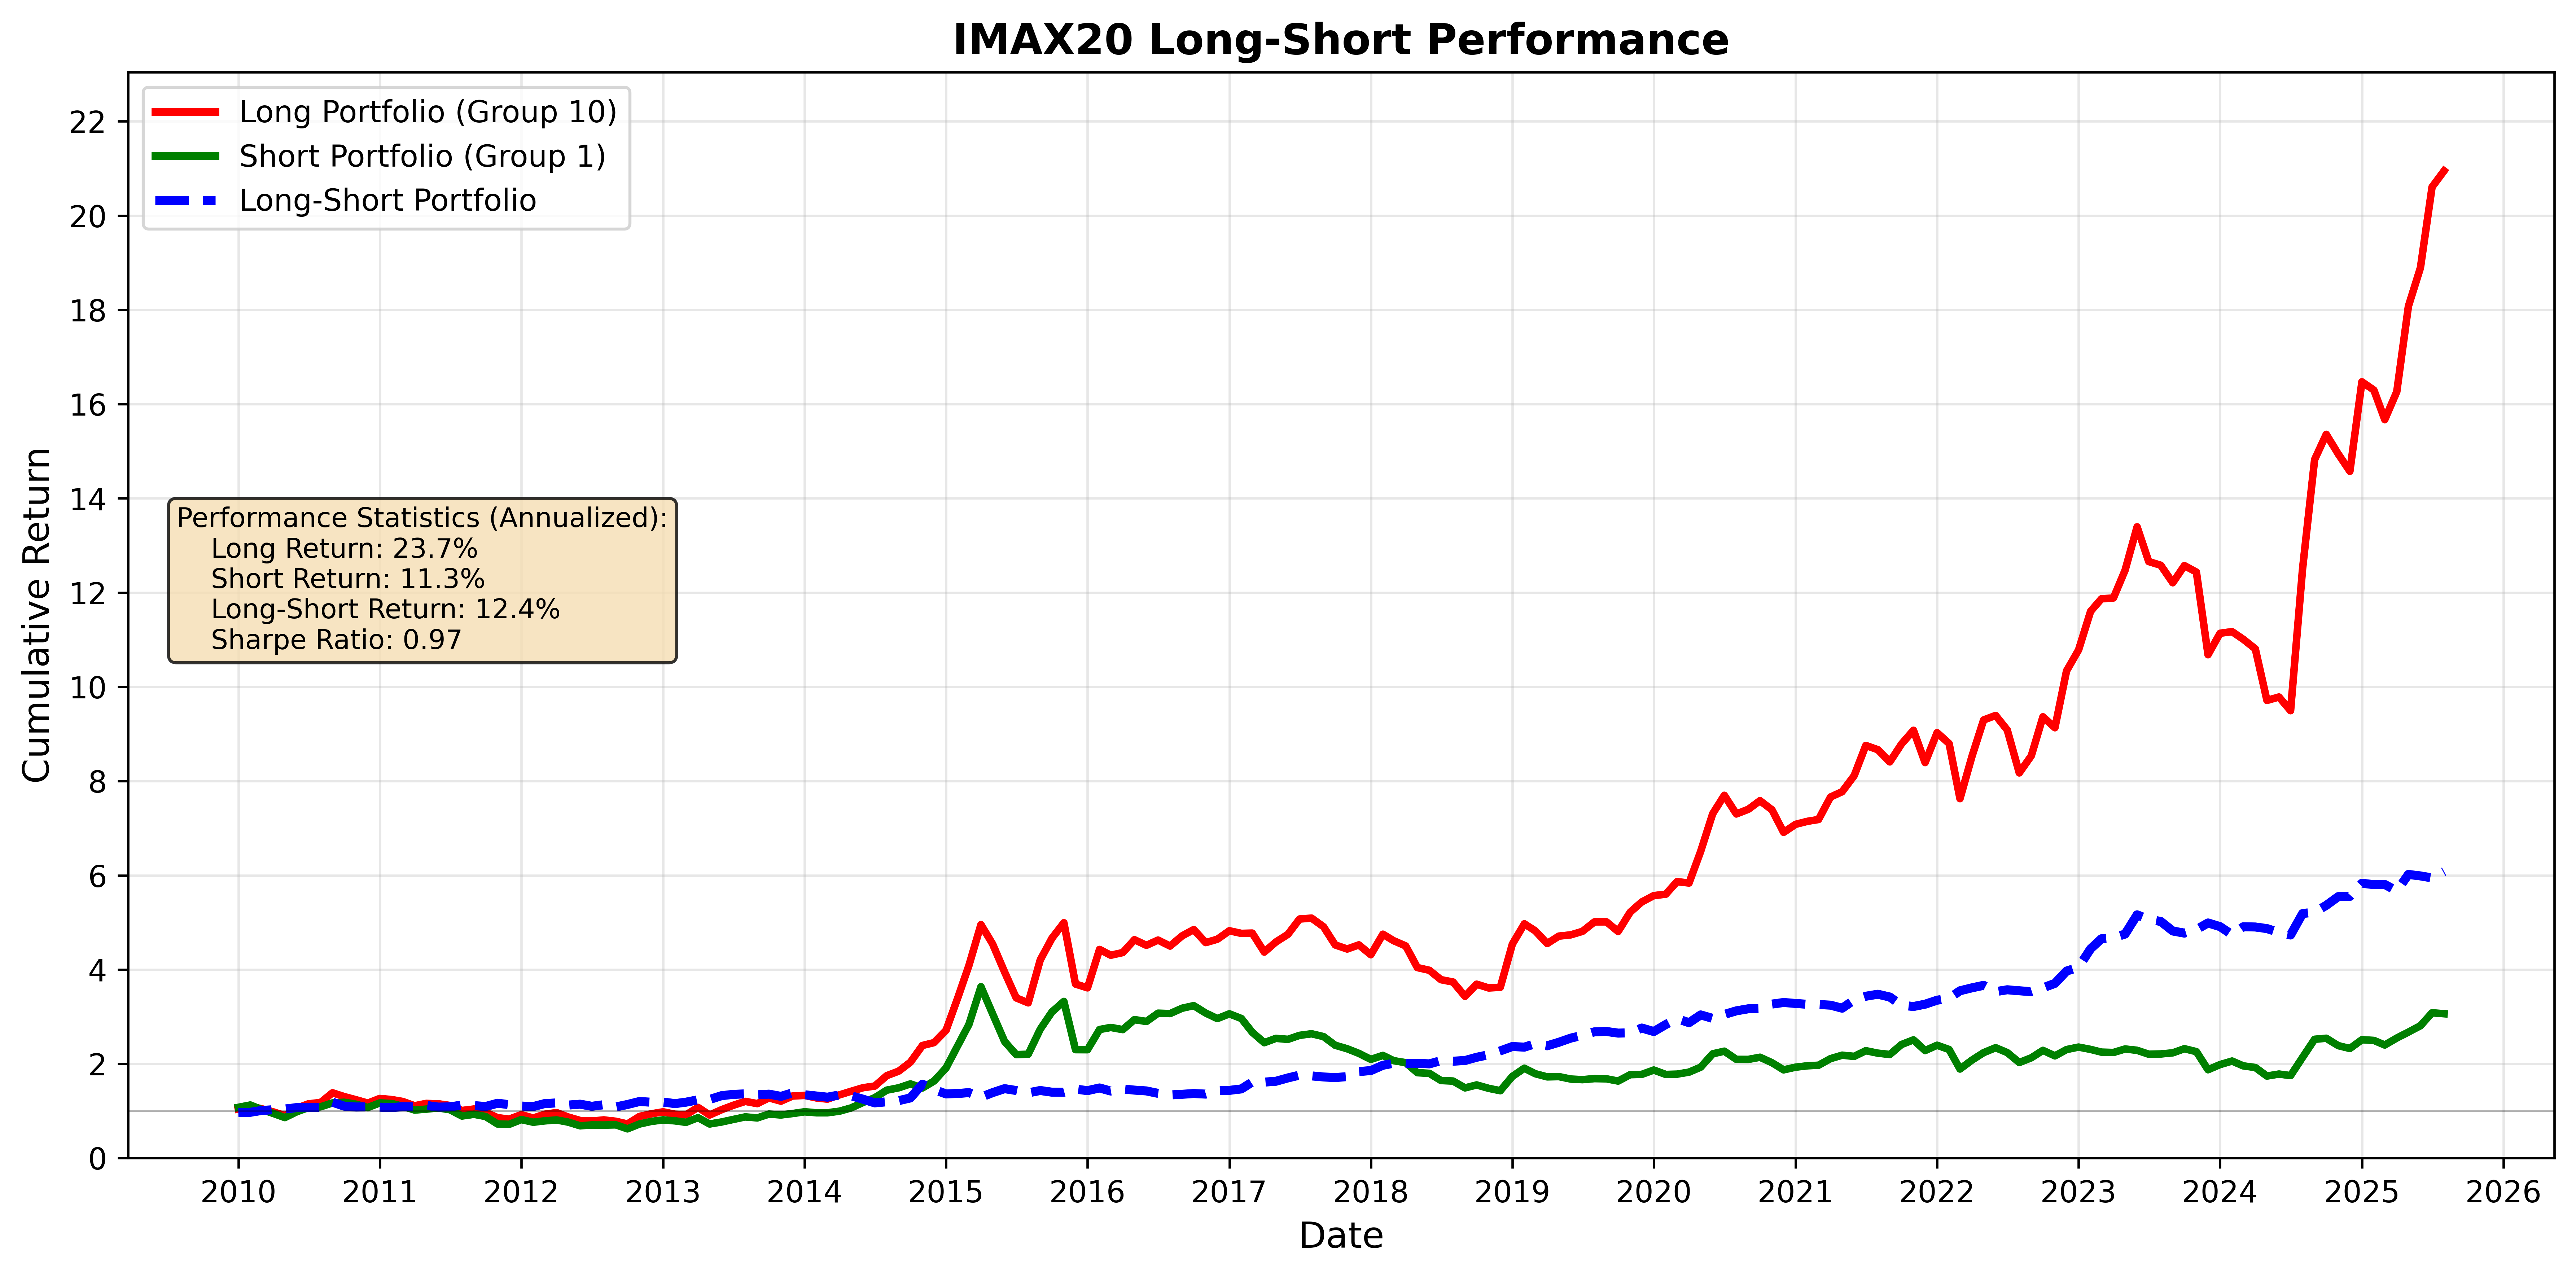

In [32]:
analyzer_imax20.plot_long_short_performance()

The IMAX20 factor demonstrates a strong positive predictive ability, presenting a significant and stable momentum effect. Since 2010, the average monthly RankIC has reached 3.68%, and the annualized ICIR has reached 1.702. The monthly excess return of the long position is 0.81%, and that of the short position is -0.22%. The return contribution of the long position is relatively large.

The performance of the IMAX20 factor also verifies our conjecture that on the day when an individual stock surges, if the "small trend" of the individual stock itself can work together with the "big trend" of the industry sector behind it, there will be stronger support in the future. However, stocks that rise independently outside the industry will face greater resistance in the future and find it difficult to maintain their upward trend.

## Resonance between individual stocks and industries: Industry joint momentum factor

We are considering weighting and fusing the industry momentum effect of the five days with the largest individual stock gains. The weight will be reduced according to the ranking of individual stock gains and losses. The greater the increase or decrease of an individual stock on a trading day, the greater the weight. This way, not only can
Making the factor values more discrete can also highlight the momentum effect of the industry on the top-ranked trading days, enhancing the effectiveness of the factor. Based on this, we constructed the Industry Joint Momentum factor ICM (Industry-Co-Momentum).

The specific calculation method of the industry joint momentum factor ICM we constructed is as follows:

$$
ICM = \sum_{i=1}^{n} w_{i}\times Ret_{d_{i},industry}
$$
$$
w_{i} = 2^{-\frac{i-1}{n-1}}
$$

Among them,$d_{1} \cdots d_{n}$ refers to the first n trading days with the largest increase or decrease of an individual stock in the past 20 days. $w_{i}$ is the weight of the i-th day, decaying in order, with a half-life of n. "industry" represents the CITIC first-level industry corresponding to an individual stock. $Ret_{d_{i},industry}$ represents the daily increase or decrease of the CITIC first-level industry index on $d_{i}$.

Taking the construction of the industry joint momentum factor with n=5 as an example, the calculation steps are:

Sort the daily price changes of the stocks over the past 20 days and find the 5 days with the largest price changes.

2. Calculate the corresponding weight $w_{i}$ for each day. The weight is attenuated based on the ranking of individual stock price fluctuations. The half-life is 5 days. Therefore, the weight of the day with the largest price fluctuation of an individual stock is 1, and the weight of the 5th day with the largest price fluctuation of an individual stock is 0.5.

3. The ICM is obtained by weighted summing the gains and losses of the first-level industry index corresponding to the five days with the largest gains and losses.

We constructed the industry joint momentum factor ICM according to the above method and tested this factor. The backtest parameters of the factor are as follows (unless otherwise specified, the backtest intervals, portfolio adjustment frequencies and stock pools of the factors in the following text are all)
(Same) :

Portfolio adjustment frequency: Monthly frequency;

Stock pool: Exclude newly listed stocks that have been on the market for less than six months, ST stocks, and ST stocks that have been delisted for less than three months.

$\cdot$ Suspension exclusion: Exclude stocks that have been suspended for more than 5 days in the past 20 trading days.


In [33]:
# First, directly exclude new stocks that have been listed for less than six months, ST stocks, and ST stocks that have been delisted for less than three months. Exclude stocks that have been suspended for more than five days in the past 20 trading days.
stock_daily = stock_daily.loc[stock_daily['is_listing_mature']&(~stock_daily['is_recently_removed_st'])&(~stock_daily['is_excessive_halt'])]
stock_daily

open     close      high       low      volume  \
trade_date code                                                            
2010-01-04 000001.SZ    6.6804    6.4598    6.6968    6.4516  24192276.0   
           000002.SZ    6.6164    6.4639    6.6286    6.4639  96983253.0   
           000006.SZ    3.1429    3.0846    3.1484    3.0818   6299805.0   
           000007.SZ    4.7257    4.6190    4.7257    4.5990   2590179.0   
           000009.SZ    4.7236    4.6548    4.7364    4.6377  17362671.0   
...                        ...       ...       ...       ...         ...   
2025-09-30 688798.SH   90.5000   92.4300   93.3300   90.2000   5246872.0   
           688799.SH   56.6800   57.1800   57.5700   55.6800   2058297.0   
           688800.SH   75.3000   75.1200   77.4500   74.1800   7683859.0   
           688819.SH   32.3700   32.7000   32.9900   32.2000   8071434.0   
           688981.SH  138.5000  140.1300  142.0000  136.6000  98622900.0   

                     is_st  trading_status  is_recently_removed_st  \
trade_date code                                                      
2010-01-04 000001.SZ     N  Normal Trading                   False   
           000002.SZ     N  Normal Trading                   False   
           000006.SZ     N  Normal Trading                   False   
           000007.SZ     Y  Normal Trading                   False   
           000009.SZ     N  Normal Trading                   False   
...                    ...             ...                     ...   
2025-09-30 688798.SH     N  Normal Trading                   False   
           688799.SH     N  Normal Trading                   False   
           688800.SH     N  Normal Trading                   False   
           688819.SH     N  Normal Trading                   False   
           688981.SH     N  Normal Trading                   False   

                      is_excessive_halt  is_listing_mature belonging_industry  
trade_date code                                                                
2010-01-04 000001.SZ              False               True           CI005021  
           000002.SZ              False               True           CI005023  
           000006.SZ              False               True           CI005023  
           000007.SZ              False               True           CI005015  
           000009.SZ              False               True           CI005023  
...                                 ...                ...                ...  
2025-09-30 688798.SH              False               True           CI005025  
           688799.SH              False               True           CI005018  
           688800.SH              False               True           CI005025  
           688819.SH              False               True           CI005011  
           688981.SH              False               True           CI005025  

[10828223 rows x 11 columns]

In [34]:
# To calculate more quickly, the factor is directly calculated from the monthly frequency level. First, obtain the trading days at the end of each month since 2010

def calculate_monthly_icm_factor(stock_daily, csi_daily, n=5, window_days=20):

    stock_df = stock_daily.reset_index()[['trade_date', 'code', 'close', 'belonging_industry']].copy()
    csi_df = csi_daily.reset_index()[['trade_date', 'code', 'pct_change']].copy()

    stock_df['trade_date'] = pd.to_datetime(stock_df['trade_date'])
    csi_df['trade_date'] = pd.to_datetime(csi_df['trade_date'])

    stock_df = stock_df.sort_values(['code', 'trade_date'])
    stock_df['daily_return'] = stock_df.groupby('code')['close'].pct_change()

    industry_return_map = {}
    for date in csi_df['trade_date'].unique():
        date_data = csi_df[csi_df['trade_date'] == date]
        industry_return_map[date] = date_data.set_index('code')['pct_change'].to_dict()

    weights = [2 ** (-(i-1)/(n-1)) for i in range(1, n+1)]
    print(f"Weight coefficient: {[f'{w:.2f}' for w in weights]}")

    stock_df['year_month'] = stock_df['trade_date'].dt.to_period('M')
    month_end_dates = stock_df.groupby('year_month')['trade_date'].max().unique()

    results = []
    
    for code, group in stock_df.groupby('code'):
        group = group.sort_values('trade_date').reset_index(drop=True) 

        for month_end_date in month_end_dates:
            if month_end_date in group['trade_date'].values:

                end_row = group.loc[group['trade_date'] == month_end_date]
                if len(end_row) == 0:
                    continue
                    
                end_idx = end_row.index[0]  
                start_idx = max(0, end_idx - window_days + 1)
                

                window_data = group.iloc[start_idx:end_idx+1].copy()  
                valid_data = window_data[window_data['daily_return'].notna()]
                
                if len(valid_data) >= n:

                    top_n_days = valid_data.nlargest(n, 'daily_return')
                    

                    icm_value = 0
                    for i, (idx, row) in enumerate(top_n_days.iterrows()):
                        industry_code = row['belonging_industry']
                        industry_ret = industry_return_map.get(row['trade_date'], {}).get(industry_code, np.nan)
                        
                        if not np.isnan(industry_ret):
                            icm_value += weights[i] * (industry_ret / 100)  
                    
                    results.append({
                        'trade_date': month_end_date,
                        'code': code,
                        'icm': icm_value
                    })
    

    if results:
        results_df = pd.DataFrame(results)
        icm_monthly = results_df.pivot_table(
            index='trade_date', 
            columns='code', 
            values='icm'
        ).sort_index()
    else:
        icm_monthly = pd.DataFrame()
    
    return icm_monthly


try:
    icm_monthly_factor = calculate_monthly_icm_factor(stock_daily, csi_daily, n=5, window_days=20)
    
    print("The monthly frequency ICM factor calculation has been completed")
    print(f"Time range: {icm_monthly_factor.index[0]} to {icm_monthly_factor.index[-1]}")
    
except Exception as e:
    print(f"Calculation error: {e}")
    print("Please check whether the input data format is correct")

Weight coefficient: ['1.00', '0.84', '0.71', '0.59', '0.50']
The monthly frequency ICM factor calculation has been completed
Time range: 2010-01-29 00:00:00 to 2025-09-30 00:00:00


In [35]:
icm_monthly_factor

code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,688786.SH,688787.SH,688788.SH,688789.SH,688793.SH,688798.SH,688799.SH,688800.SH,688819.SH,688981.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2010-01-29,0.052695,0.043334,NaN,0.055407,0.048766,NaN,0.057059,0.031930,0.006727,0.044722,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-26,0.063687,0.076258,NaN,0.042513,0.035245,0.030656,0.052392,0.023810,0.045289,0.041000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,0.076404,0.068039,NaN,0.069994,0.037906,0.041004,0.031284,0.007693,-0.008029,0.034426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,0.036914,0.019956,0.064227,0.043502,NaN,0.031303,0.013040,NaN,0.022220,0.040691,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,0.088160,0.141004,0.089528,0.134073,-0.000033,NaN,0.109384,NaN,0.119239,0.073896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-30,0.037163,0.033075,-0.000654,0.036102,-0.029616,0.065553,0.055469,0.024567,0.038437,0.032074,...,0.022068,0.025815,0.049912,0.002406,0.020616,0.048349,0.033528,0.027632,0.059846,0.050559
2025-06-30,0.045390,0.047260,0.058754,0.020463,0.017114,0.036248,0.072795,0.029283,0.031321,0.031101,...,0.013499,0.060164,0.098386,0.010123,-0.010092,0.040640,0.045154,0.044245,0.060309,0.056683
2025-07-31,0.035352,0.065913,0.026753,0.061963,0.018233,0.041827,0.029128,0.042384,0.062251,0.107823,...,0.037505,0.037703,0.048638,0.005081,-0.000795,0.039961,0.016180,0.029365,0.050519,0.048178


In [36]:
# Backtesting results of ICM factors
analyzer = MonthlyFactorAnalyzer(
    factor_panel=icm_monthly_factor, 
    price_panel=price_panel, 
    factor_name="ICM"
)
results = analyzer.analyze_factor()
plt.show()

Starting analysis for ICM factor...
RankIC analysis completed. Time range: 2010-01-01 00:00:00 to 2025-08-01 00:00:00
Total months analyzed: 188
Group excess returns analysis completed
Group range in results: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

ICM Factor Performance Summary:
Monthly RankIC Mean: 0.0409
Annualized ICIR: 1.541
Hit Rate: 65.43%

Group Excess Returns (%):
Group 1: -0.88%
Group 2: -0.41%
Group 3: -0.18%
Group 4: -0.06%
Group 5: 0.01%
Group 6: 0.20%
Group 7: 0.26%
Group 8: 0.28%
Group 9: 0.36%
Group 10: 0.42%


The average RankIC of the final obtained ICM factor was 4.09%, and the annualized ICIR reached 1.541. The monthly excess return of the long position was 0.42%, and that of the short position was -0.88%, demonstrating strong predictive ability and stability.

In addition to the stock price dimension, trading volume can also provide effective information on the trend of individual stocks. When an individual stock surges, if it is accompanied by an effective increase in trading volume and a simultaneous rise in both volume and price, it may be a positive signal, indicating that some institutional investors have paid attention to the stock and started to build positions.

If the dimension of trading volume is included, and the individual stocks are sorted by their daily frequency (increase or decrease × trading volume), the maximum 5 days of this indicator are selected, and the corresponding industry returns are weighted and summed, and it is named the industry joint momentum factor of both volume and price increase
VICM (Volume-Industry-Co-Momentum), the calculation method of VICM is as follows:

$$
VICM = \sum_{i=1}^{n} w_{i} \times Ret_{d_{i,industry}}
$$
$$
w_{i} = 2^{-\frac{i-1}{n-1}}
$$

Among them, $d_{1} \cdots d_{n}$ refers to the largest first n trading days of an individual stock in the past 20 days (change in price × trading volume), $w_{i}$ is the weight of the i-th day, decaying in order, with a half-life of n. "industry" represents the corresponding CITIC first-level industry for individual stocks. $Ret_{d_{i,industry}}$ is the daily increase or decrease of the CITIC first-level industry index on $d_{i}$ . This sorting method will make the days when individual stocks have a significant increase in volume and price rank higher, distinguishing the trading days with both volume and price rising.

Calculation steps for the joint momentum factor (VICM) of the industry with both volume and price rising

Sort the daily (increase or decrease × trading volume) of the stock over the past 20 days and find the 5 days with the largest volume.

2. Calculate the corresponding weight $w_{i}$ . The weight decays based on the ranking of (change in price × trading volume), with a half-life of 5 days.

3. The weighted sum of the industry's price changes corresponding to the five days with the largest daily increase (price change × trading volume) is obtained as VICM.

In [37]:
def calculate_monthly_vicm_factor(stock_daily, csi_daily, n=5, window_days=20):

    stock_df = stock_daily.reset_index()[['trade_date', 'code', 'close', 'volume', 'belonging_industry']].copy()
    csi_df = csi_daily.reset_index()[['trade_date', 'code', 'pct_change']].copy()
    
    stock_df['trade_date'] = pd.to_datetime(stock_df['trade_date'])
    csi_df['trade_date'] = pd.to_datetime(csi_df['trade_date'])
    
    stock_df = stock_df.sort_values(['code', 'trade_date'])
    stock_df['daily_return'] = stock_df.groupby('code')['close'].pct_change()
    stock_df['price_volume_metric'] = stock_df['daily_return'] * stock_df['volume']
    
    industry_return_map = {}
    for date in csi_df['trade_date'].unique():
        date_data = csi_df[csi_df['trade_date'] == date]
        industry_return_map[date] = date_data.set_index('code')['pct_change'].to_dict()
    
    weights = [2 ** (-(i-1)/(n-1)) for i in range(1, n+1)]
    print(f"VICM Weight coefficient: {[f'{w:.2f}' for w in weights]}")
    
    stock_df['year_month'] = stock_df['trade_date'].dt.to_period('M')
    month_end_dates = stock_df.groupby('year_month')['trade_date'].max().unique()
    
    results = []
    
    for code, group in stock_df.groupby('code'):
        group = group.sort_values('trade_date').reset_index(drop=True)
        
        for month_end_date in month_end_dates:
            if month_end_date in group['trade_date'].values:

                end_row = group[group['trade_date'] == month_end_date]
                if len(end_row) == 0:
                    continue
                    
                end_idx = end_row.index[0]
                start_idx = max(0, end_idx - window_days + 1)
                
                window_data = group.iloc[start_idx:end_idx+1].copy()
                valid_data = window_data[window_data['price_volume_metric'].notna()]
                
                if len(valid_data) >= n:
     
                    top_n_days = valid_data.nlargest(n, 'price_volume_metric')
                    

                    vicm_value = 0
                    for i, (idx, row) in enumerate(top_n_days.iterrows()):
                        industry_code = row['belonging_industry']
                        industry_ret = industry_return_map.get(row['trade_date'], {}).get(industry_code, np.nan)
                        
                        if not np.isnan(industry_ret):
                            vicm_value += weights[i] * (industry_ret / 100) 
                    
                    results.append({
                        'trade_date': month_end_date,
                        'code': code,
                        'vicm': vicm_value
                    })
    

    if results:
        results_df = pd.DataFrame(results)
        vicm_monthly = results_df.pivot_table(
            index='trade_date', 
            columns='code', 
            values='vicm'
        ).sort_index()
    else:
        vicm_monthly = pd.DataFrame()
    
    return vicm_monthly

# 使用示例
try:
    vicm_monthly_factor = calculate_monthly_vicm_factor(stock_daily, csi_daily, n=5, window_days=20)
    
    print("The monthly frequency VICM factor calculation has been completed")
    print(f"Time range: {vicm_monthly_factor.index[0]} to {vicm_monthly_factor.index[-1]}")
    print(f"The number of covered stocks: {len(vicm_monthly_factor.columns)}")
    
except Exception as e:
    print(f"Calculation error: {e}")
    print("Please check whether the input data format is correct")

VICM Weight coefficient: ['1.00', '0.84', '0.71', '0.59', '0.50']
The monthly frequency VICM factor calculation has been completed
Time range: 2010-01-29 00:00:00 to 2025-09-30 00:00:00
The number of covered stocks: 5119


In [38]:
vicm_monthly_factor

code,000001.SZ,000002.SZ,000004.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,000012.SZ,...,688786.SH,688787.SH,688788.SH,688789.SH,688793.SH,688798.SH,688799.SH,688800.SH,688819.SH,688981.SH
trade_date,,,,,,,,,,,,,,,,,,,,,
2010-01-29,0.054856,0.046377,NaN,0.056569,0.050519,NaN,0.046844,0.053605,0.010597,0.042643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-26,0.063713,0.063129,NaN,0.037473,0.035319,0.030656,0.046192,0.021899,0.053228,0.041000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,0.075655,0.067043,NaN,0.058099,0.025594,0.024761,0.029625,-0.000769,-0.029875,0.032619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,0.037563,0.029719,0.063587,0.043502,NaN,0.028956,0.009347,NaN,0.023503,0.038941,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,0.091306,0.140370,0.090732,0.131017,-0.004655,NaN,0.103759,NaN,0.113184,0.071528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-30,0.037242,0.032698,-0.024967,0.020166,-0.021638,0.053716,0.055469,0.019632,0.033060,0.033412,...,0.022068,0.023176,0.074664,-0.000858,0.021097,0.051094,0.027328,0.008676,0.059004,0.061059
2025-06-30,0.043729,0.047260,0.055431,0.021736,0.017193,0.026245,0.081145,0.019212,0.039654,0.026601,...,0.018174,0.060164,0.067782,0.020005,-0.010092,0.041940,0.045154,0.039627,0.059536,0.056683
2025-07-31,0.035352,0.066742,0.026753,0.061119,0.018233,0.042677,0.034349,0.063371,0.061519,0.100600,...,0.027918,0.034453,0.033721,0.003623,-0.001895,0.039275,0.022730,0.026582,0.049931,0.048175


In [39]:
# Backtesting results of VICM factors
analyzer = MonthlyFactorAnalyzer(
    factor_panel=vicm_monthly_factor, 
    price_panel=price_panel, 
    factor_name="VICM"
)
results = analyzer.analyze_factor()
plt.show()

Starting analysis for VICM factor...
RankIC analysis completed. Time range: 2010-01-01 00:00:00 to 2025-08-01 00:00:00
Total months analyzed: 188
Group excess returns analysis completed
Group range in results: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

VICM Factor Performance Summary:
Monthly RankIC Mean: 0.0448
Annualized ICIR: 1.705
Hit Rate: 69.68%

Group Excess Returns (%):
Group 1: -0.92%
Group 2: -0.49%
Group 3: -0.19%
Group 4: -0.04%
Group 5: 0.07%
Group 6: 0.24%
Group 7: 0.20%
Group 8: 0.31%
Group 9: 0.39%
Group 10: 0.42%


The average value of the VICM factor, which considers trading volume, rose from 4.09% to 4.48% compared with the industry joint momentum factor ranked only by change in price, and the annualized ICIR increased to 1.705. The monthly excess return for long positions was 0.42%.
The monthly excess return of short sellers was -0.92%. The joint momentum factor of the short market has improved to a certain extent compared with the original industry, while that of the long market remains unchanged. In addition, the winning rate also increased from 65.43% to 69.68%. That is, on the day when both the volume and price of an individual stock rise, the momentum effect of the industry's rise and fall is more significant, and it is different from the individual stock reversal factor. The contribution of this factor to the long position's income is also higher.

Now let's take a look at the long and short net worth curves of the ICM factor and the VICM factor

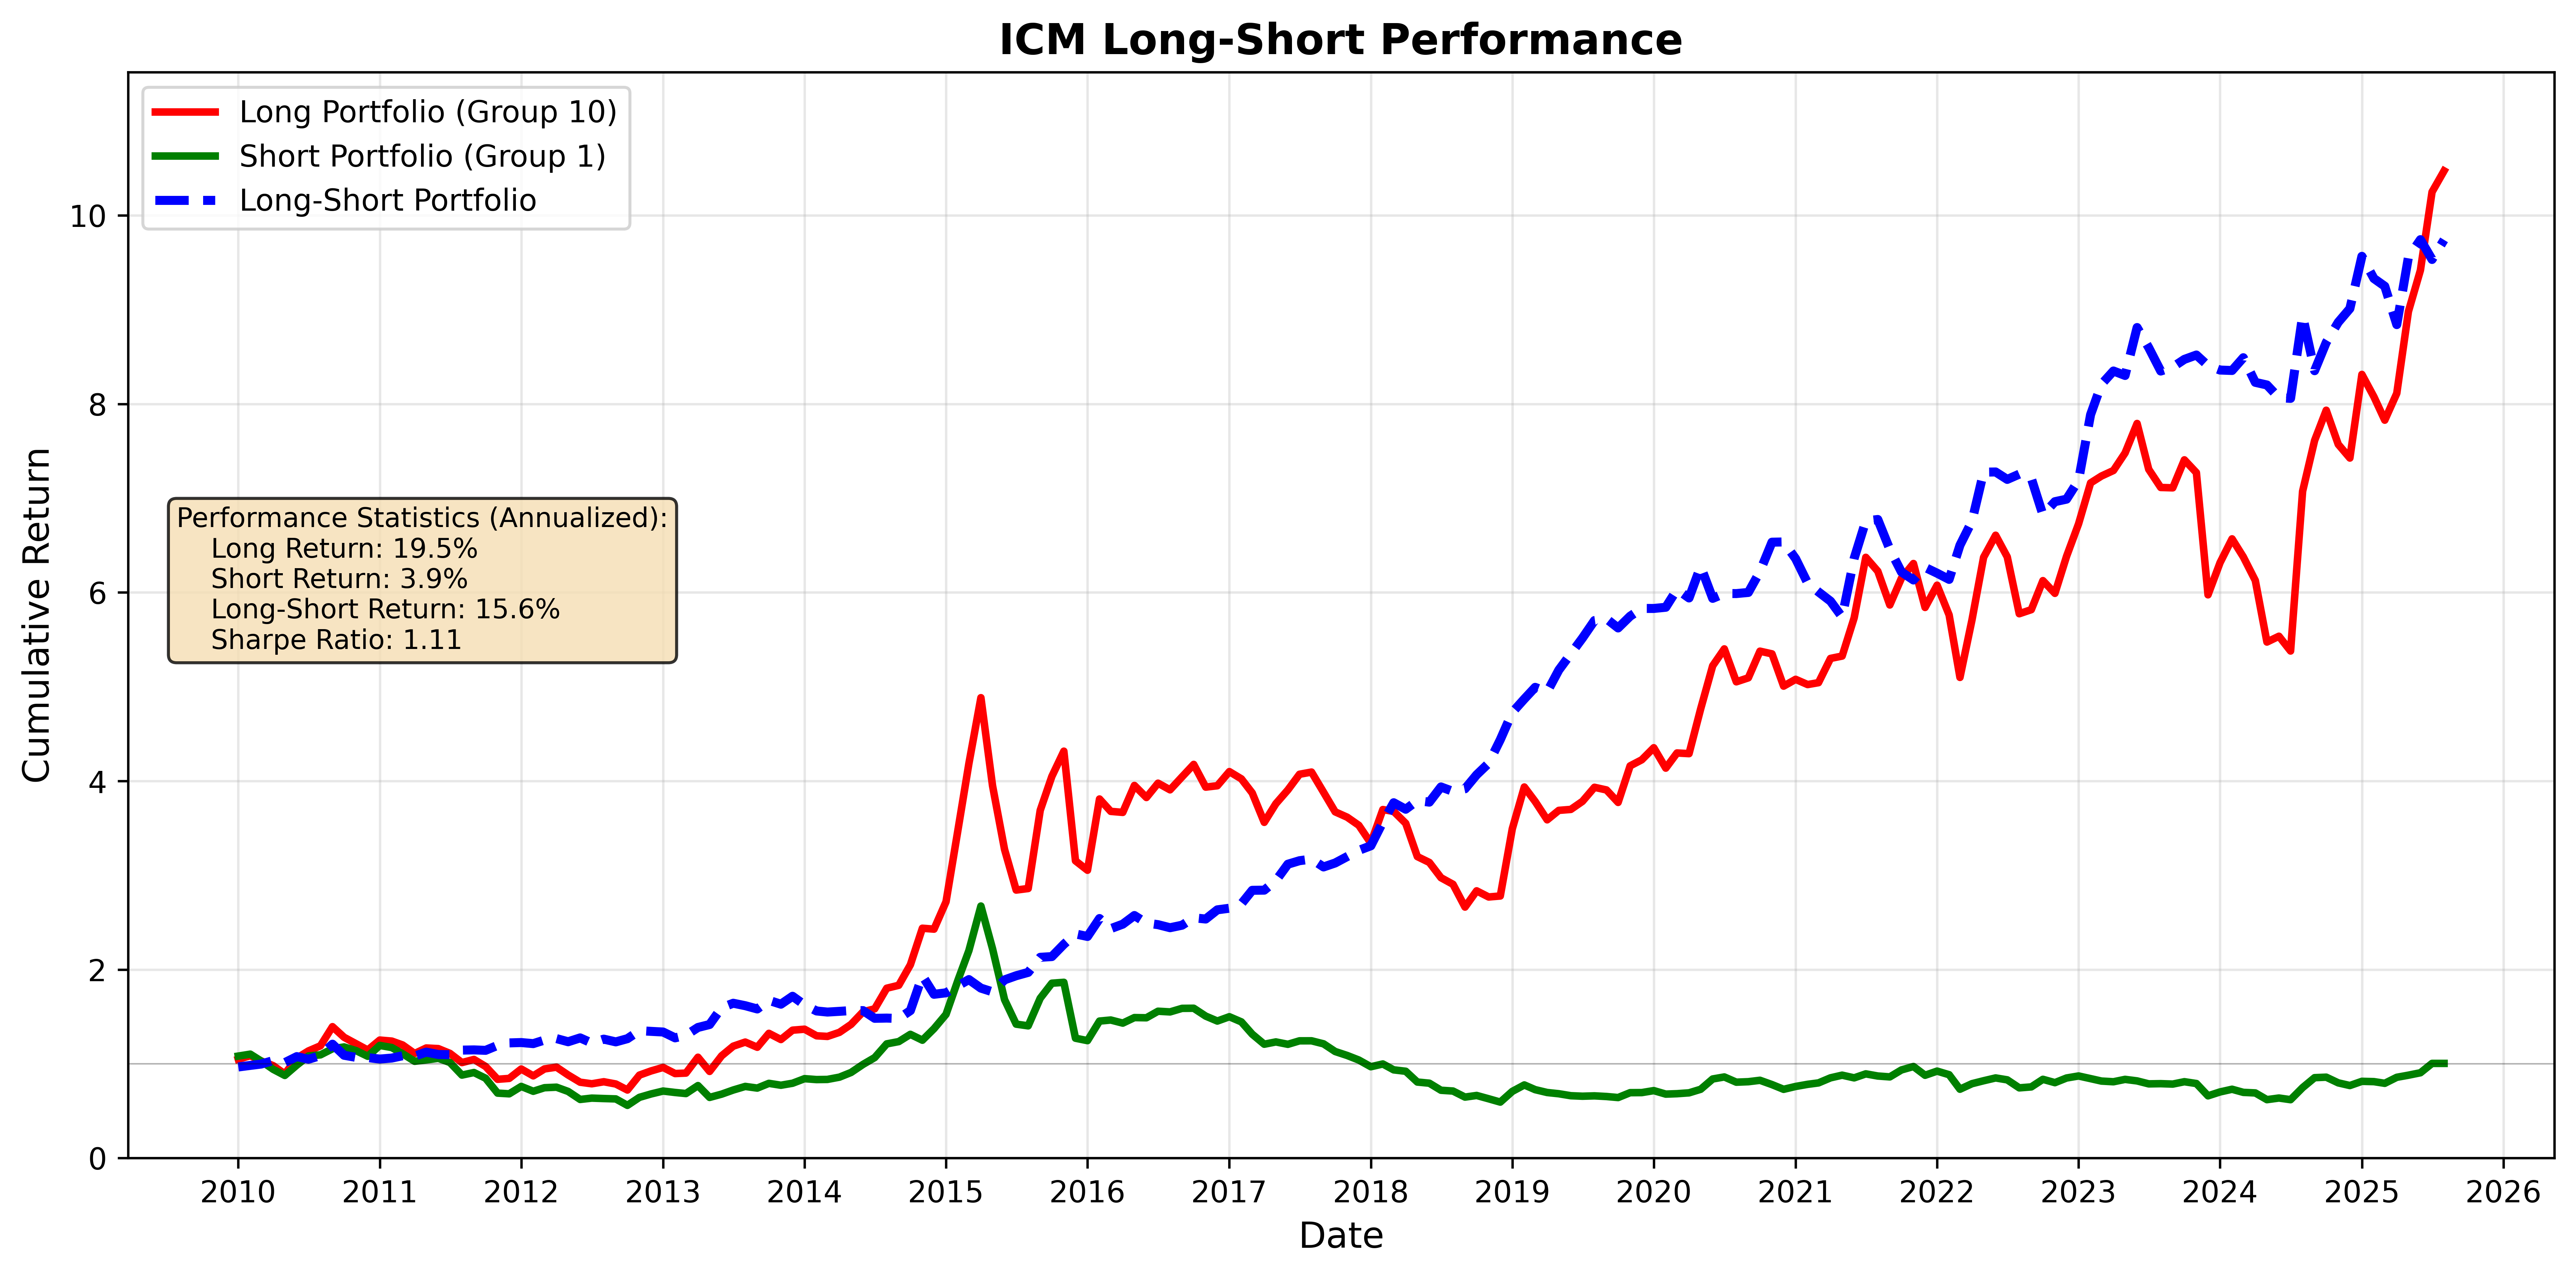

In [41]:
# ICM Long and Short net worth curve
analyzer_icm = MonthlyFactorAnalyzer(icm_monthly_factor, price_panel, "ICM")
analyzer_icm.plot_long_short_performance()

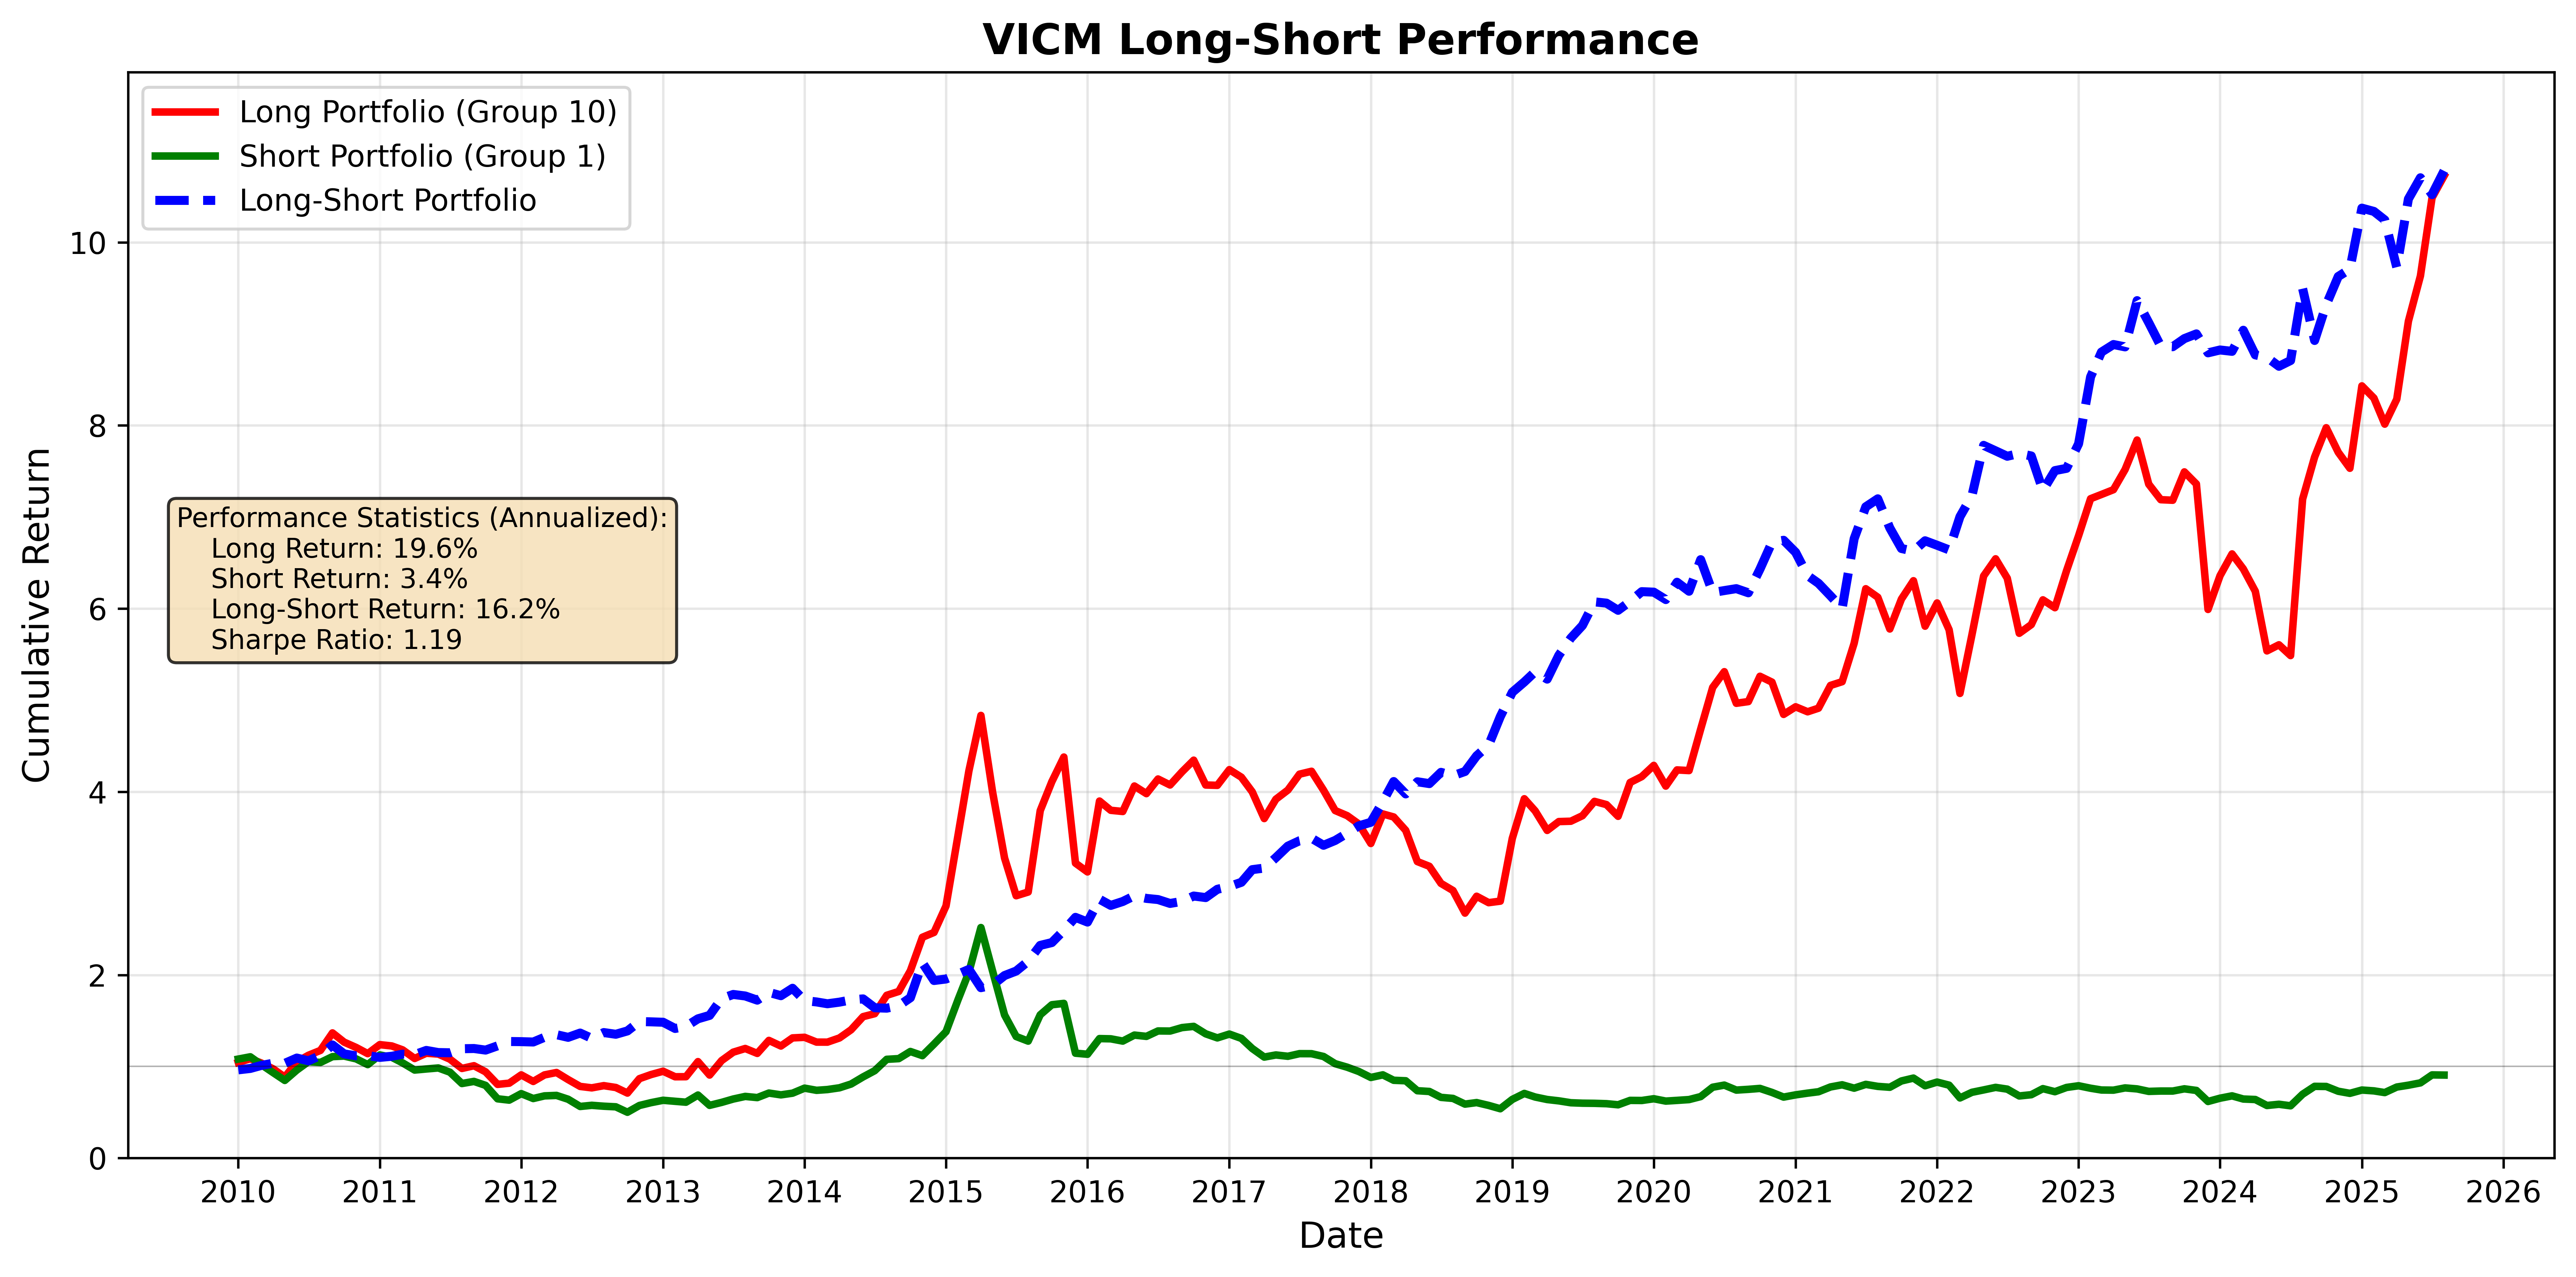

In [40]:
# VICM Long and Short net worth curve
analyzer_vicm = MonthlyFactorAnalyzer(vicm_monthly_factor, price_panel, "VICM")
analyzer_vicm.plot_long_short_performance()

Obviously, the VICM effect is better than that of ICM. However, compared with the IMAX20 factor mentioned earlier, the long position effect is significantly lower than that of the IMAX factor. The annualized return of the IMAX long position has reached 23.7%, and the strategy effect has been very strong since the beginning of this year! However, the VICM long position is only 19.6%. So, does the VICM factor have any advantages over the IMAX20 factor? Of course it does. The long and short effect and Sharpe of VICM are both better than those of IMAX20.